In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.svm import SVC

In [3]:
#Function 1
input_data_1 = np.load('initial_data/function_1/initial_inputs.npy')
output_data_1 = np.load('initial_data/function_1/initial_outputs.npy')
# include new data from week 1
input_data_1 = np.append(input_data_1, [[0.838384, 0.767677]], axis=0)
output_data_1 = np.append(output_data_1, -6.893705068847273e-45)
# include new data from week 2
input_data_1 = np.append(input_data_1, [[0.766917, 0.775188]], axis=0)
output_data_1 = np.append(output_data_1, 7.549535198911049e-29)
# include new data from week 3
input_data_1 = np.append(input_data_1, [[0.818182, 0.678322]], axis=0)
output_data_1 = np.append(output_data_1, -4.195357984960884e-28)
# include new data from week 4
input_data_1 = np.append(input_data_1, [[0.696429, 0.791667]], axis=0)
output_data_1 = np.append(output_data_1, -3.5814423788043363e-22)

In [4]:
print(input_data_1)
print(input_data_1.shape)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.838384   0.767677  ]
 [0.766917   0.775188  ]
 [0.818182   0.678322  ]
 [0.696429   0.791667  ]]
(14, 2)


In [5]:
print(output_data_1)
print(output_data_1.shape)
print(np.sort(output_data_1))

[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -6.89370507e-045  7.54953520e-029
 -4.19535798e-028 -3.58144238e-022]
(14,)
[-3.60606264e-003 -3.58144238e-022 -4.19535798e-028 -6.89370507e-045
 -2.15924904e-054 -2.08909327e-091  3.34177101e-124  3.60677119e-081
  1.32267704e-079  6.22985647e-048  1.03307824e-046  2.53500115e-040
  7.54953520e-029  7.71087511e-016]


In [6]:
### The outcome from week 4 is very poor
# In this round, I considered noise and after filtering based on 1e-30, I am left with 5 data points which I consider too small for the model.
# So I decided to manually select points which I believe to be more exploratory but not too far from the current maximum outcome
# New input is 0.500000-0.500000

[[0.73102363 0.73299988]
 [0.65011406 0.68152635]
 [0.766917   0.775188  ]
 [0.818182   0.678322  ]
 [0.696429   0.791667  ]]
[ 0.5 -2.   0.5  0.5  0.5]
3.9236537578215382
[0.589744 0.969231]


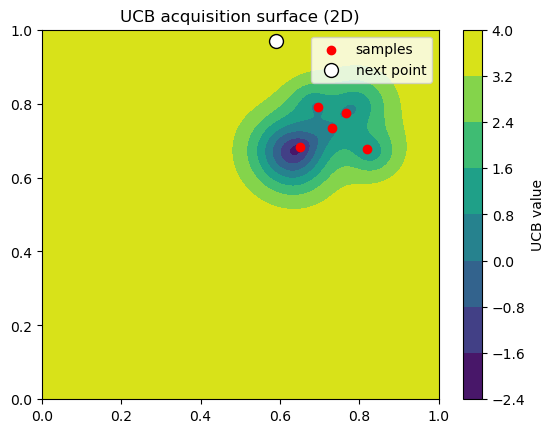

In [31]:
noise_assumption = 1e-30

rbf_lengthscale = 0.09

#Acquisition function parameter
beta = 3.9

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
X = input_data_1
Y = output_data_1

# manually remove noise
mask = np.abs(Y) >= noise_assumption
X = X[mask]
Y = Y[mask]
print(X)
Y = (Y - Y.mean()) / Y.std() #standardise data to account for very small values
print(Y)
#Initialise grid for plots
grid_x = np.linspace(0, 1, len(output_data_1)**2)
grid_y = np.linspace(0, 1, len(output_data_1)**2)
xx, yy = np.meshgrid(grid_x, grid_y)
x_grid = np.c_[xx.ravel(), yy.ravel()]

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

#Calculate the mean and standard deviation
post_mean, post_std = model.predict(x_grid, return_std=True)

# UCB acquisition
acquisition_function = post_mean + beta * post_std

print(np.max(acquisition_function))
"""
#EI acquisition
xi = 0.01
f_best = np.max(Y)
improvement = post_mean - f_best - xi
z = improvement / post_std
acquisition_function = improvement * norm.cdf(z) + post_std * norm.pdf(z)
acquisition_function[post_std == 0.0] = 0.0
"""
X_next = x_grid[np.argmax(acquisition_function)]

print(np.round(X_next, decimals=6))

# -----------------------
# 8. Plot UCB surface
# -----------------------
plt.contourf(xx, yy, acquisition_function.reshape(xx.shape))
plt.colorbar(label="UCB value")
plt.scatter(X[:,0], X[:,1], c='red', label="samples")
plt.scatter(X_next[0], X_next[1], c='white', edgecolor='black', s=100, label="next point")
plt.legend()
plt.title("UCB acquisition surface (2D)")
plt.show()

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.818182   0.939394  ]
 [0.621053   0.987218  ]
 [0.215981   0.660104  ]
 [0.684524   0.309524  ]]
(14, 2)
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.05218796  0.35089095
 -0.11245845  0.68358114]
(14,)
(38416, 2)
Next:  [0.830769 0.215385]


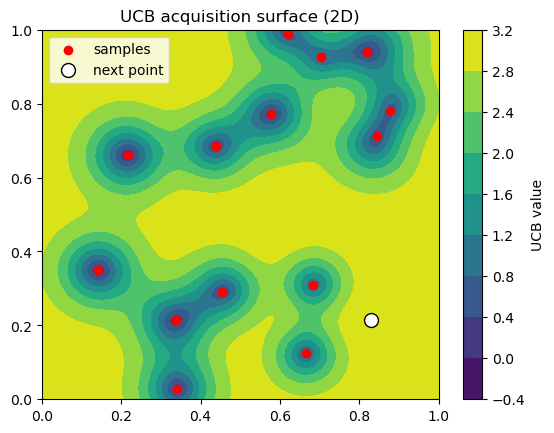

In [34]:
#Function 2
# Outcome from week 4 is the best of all outcomes for this function so far, staying explorative in the last round yielded promising outcome
# I am staying explorative again for this round, to cover more
# uncertain regions before exploiting due to multipeak nature of the function's data
input_data_2 = np.load('initial_data/function_2/initial_inputs.npy')
output_data_2 = np.load('initial_data/function_2/initial_outputs.npy')
# include new data from week 1
input_data_2 = np.append(input_data_2, [[0.818182, 0.939394]], axis=0)
output_data_2 = np.append(output_data_2, 0.052187964293633496)
# include new data from week 2
input_data_2 = np.append(input_data_2, [[0.621053, 0.987218]], axis=0)
output_data_2 = np.append(output_data_2, 0.3508909522243821)
# include new data from week 3
input_data_2 = np.append(input_data_2, [[0.215981, 0.660104]], axis=0)
output_data_2 = np.append(output_data_2, -0.11245844564734742)
# include new data from week 3
input_data_2 = np.append(input_data_2, [[0.684524, 0.309524]], axis=0)
output_data_2 = np.append(output_data_2, 0.6835811441905567)

print(input_data_2)
print(input_data_2.shape)
print(output_data_2)
print(output_data_2.shape)

real_noise_std = 1e-6
noise_assumption = 1e-6
rbf_lengthscale = 0.1

#Acquisition function parameter
beta = 3 # 2 or higher to target multipeaks

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_2
Y = output_data_2

#Initialise grid for plots
grid_x = np.linspace(0, 1, len(output_data_2)**2)
grid_y = np.linspace(0, 1, len(output_data_2)**2)
xx, yy = np.meshgrid(grid_x, grid_y)
x_grid = np.c_[xx.ravel(), yy.ravel()]
print(x_grid.shape)

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

#Calculate the mean and standard deviation
post_mean, post_std = model.predict(x_grid, return_std=True)

# UCB acquisition
acquisition_function = post_mean + beta * post_std

X_next = x_grid[np.argmax(acquisition_function)]

print('Next: ', (np.round(X_next, decimals=6)))

# -----------------------
# 8. Plot UCB surface
# -----------------------
plt.contourf(xx, yy, acquisition_function.reshape(xx.shape))
plt.colorbar(label="UCB value")
plt.scatter(X[:,0], X[:,1], c='red', label="samples")
plt.scatter(X_next[0], X_next[1], c='white', edgecolor='black', s=100, label="next point")
plt.legend()
plt.title("UCB acquisition surface (2D)")
plt.show()

In [36]:
# Function 3
# ******** Outcome from week 4 is worse than week 3*****
# Moving from exploration to exploitation
input_data_3 = np.load('initial_data/function_3/initial_inputs.npy')
output_data_3 = np.load('initial_data/function_3/initial_outputs.npy')
# include new data from week 1
input_data_3 = np.append(input_data_3, [[0.414145, 0.390256, 0.511599]], axis=0)
output_data_3 = np.append(output_data_3, -0.010572017488314756)
# include new data from week 2
input_data_3 = np.append(input_data_3, [[0.486811, 0.675060, 0.592334]], axis=0)
output_data_3 = np.append(output_data_3, -0.050701081879245206)
# include new data from week 3
input_data_3 = np.append(input_data_3, [[0.394017, 0.116418, 0.453656]], axis=0)
output_data_3 = np.append(output_data_3, -0.056130798616076505)
# include new data from week 4
input_data_3 = np.append(input_data_3, [[0.436577, 0.098114, 0.081182]], axis=0)
output_data_3 = np.append(output_data_3, -0.08169605401754566)

print(input_data_3)
print(input_data_3.shape)
print(output_data_3)
print(output_data_3.shape)
print(np.sort(output_data_3))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.2

#Acquisition function parameter
beta = 0.96

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_3
y = output_data_3 # sample already negated to transform from minimisation to maximisation problem
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=5):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=3)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1), (0, 1), (0, 1)]
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.414145   0.390256   0.511599  ]
 [0.486811   0.67506    0.592334  ]
 [0.394017   0.116418   0.453656  ]
 [0.436577   0.098114   0.081182  ]]
(19, 3)
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.01057202 -0.05070108 -0.0561308
 -0.08169605]
(19,)
[-0.39892551 -0.13146061 -0.11804826 -0.11386851 -0.1121222  -0.11141

In [57]:
# Function 4
# Outcome from week 3 is the highest so far.
# Although exploration is giving good outcome, I am now increasing exploitation a bit more to target global peak
input_data_4 = np.load('initial_data/function_4/initial_inputs.npy')
output_data_4 = np.load('initial_data/function_4/initial_outputs.npy')
# include new data from week 1
input_data_4 = np.append(input_data_4, [[0.383229, 0.487977, 0.445785, 0.398437]], axis=0)
output_data_4 = np.append(output_data_4, -1.590305706105521)
# include new data from week 2
input_data_4 = np.append(input_data_4, [[0.400989, 0.278541, 0.491673, 0.336468]], axis=0)
output_data_4 = np.append(output_data_4, -2.3158733786992047)
# include new data from week 3
input_data_4 = np.append(input_data_4, [[0.409478, 0.391879, 0.282717, 0.415204]], axis=0)
output_data_4 = np.append(output_data_4, -1.2770762561275926)
# include new data from week 4
input_data_4 = np.append(input_data_4, [[0.387895, 0.389004, 0.382921, 0.398504]], axis=0)
output_data_4 = np.append(output_data_4, -0.0542073695661176)

print(input_data_4)
print(input_data_4.shape)
print(output_data_4)
print(output_data_4.shape)
print(np.max(output_data_4))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.7

#Acquisition function parameter
beta = 1.96 # from 3 to 1.96

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_4
y = output_data_4
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=10):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=4)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [39]:
# Function 5
# ******** Second best outcome from week 4 *****
# As a single peak problem, staying more exploitative is yielding good results
# Reducing length scale to open room for more exploitation
input_data_5 = np.load('initial_data/function_5/initial_inputs.npy')
output_data_5 = np.load('initial_data/function_5/initial_outputs.npy')
# include new data from week 1
input_data_5 = np.append(input_data_5, [[0.240893, 0.843693, 0.902123, 0.884136]], axis=0)
output_data_5 = np.append(output_data_5, 1219.608721581588)
# include new data from week 2
input_data_5 = np.append(input_data_5, [[0.317538, 0.830816, 0.999037, 0.910426]], axis=0)
output_data_5 = np.append(output_data_5, 2026.179144193655)
# include new data from week 3
input_data_5 = np.append(input_data_5, [[0.410003, 0.815208, 1.000000, 0.942739]], axis=0)
output_data_5 = np.append(output_data_5, 2246.3443545869577)
# include new data from week 4
input_data_5 = np.append(input_data_5, [[0.377888, 0.820623, 0.993501, 0.931560]], axis=0)
output_data_5 = np.append(output_data_5, 2102.865502812711)
print(input_data_5)
print(input_data_5.shape)
print(output_data_5)
print(output_data_5.shape)

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.07 #from 0.1 to 0.07

#Acquisition function parameter
beta = 0.3 # made very low to target single peak

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_5
y = output_data_5
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=8):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=4)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.240893   0.843693   0.902123   0.884136  ]
 [0.317538   

In [41]:
# Function 6
# ******** Outcome from week 4 was below week 3 and 2, third best *****
# I think the model in now stucked in a local minima and will tune hyperparameters to be more explorative in this round
input_data_6 = np.load('initial_data/function_6/initial_inputs.npy')
output_data_6 = np.load('initial_data/function_6/initial_outputs.npy')
# include new data from week 1
input_data_6 = np.append(input_data_6, [[0.121112, 0.747291, 0.134791, 0.181530, 0.905414]], axis=0)
output_data_6 = np.append(output_data_6, -2.541717267047471)
# include new data from week 2
input_data_6 = np.append(input_data_6, [[0.536018, 0.367759, 0.530592, 0.692008, 0.201616]], axis=0)
output_data_6 = np.append(output_data_6, -0.40693155582108453)
# include new data from week 3
input_data_6 = np.append(input_data_6, [[0.557141, 0.229501, 0.537493, 0.902845, 0.212100]], axis=0)
output_data_6 = np.append(output_data_6, -0.5959931296928154)
# include new data from week 4
input_data_6 = np.append(input_data_6, [[0.628154, 0.311627, 0.507768, 0.712528, 0.208888]], axis=0)
output_data_6 = np.append(output_data_6, -0.6209173855022058)
print(input_data_6)
print(input_data_6.shape)
print(output_data_6)
print(output_data_6.shape)
print(np.max(output_data_6))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.3

#Acquisition function parameter
beta = 2.96 # from 0.6 to 2.96

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_6
y = output_data_6
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    return post_mean + beta * post_std


# Find Next Point
def propose_next(gp, bounds, n_restarts=10):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=5)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1)] * 5 # set based on input dimensions
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [42]:
# Function 7
# ******** Outcome from week 4 is the best so far, SVM application yielded significant improvement *****
# I am maintaining same configuration for this round
input_data_7 = np.load('initial_data/function_7/initial_inputs.npy')
output_data_7 = np.load('initial_data/function_7/initial_outputs.npy')
# include new data from week 1
input_data_7 = np.append(input_data_7, [[0.018984, 0.392236, 0.325329, 0.152246, 0.349321, 0.732852]], axis=0)
output_data_7 = np.append(output_data_7, 1.7961746346703364)
# include new data from week 2
input_data_7 = np.append(input_data_7, [[0.064580, 0.291499, 0.426406, 0.163732, 0.339003, 0.806973]], axis=0)
output_data_7 = np.append(output_data_7, 2.117081006805383)
# include new data from week 3
input_data_7 = np.append(input_data_7, [[0.035600, 0.363328, 0.468372, 0.104617, 0.358856, 0.924795]], axis=0)
output_data_7 = np.append(output_data_7, 1.1321056317369929)
# include new data from week 4
input_data_7 = np.append(input_data_7, [[0.079866, 0.187293, 0.413550, 0.208962, 0.326153, 0.742298]], axis=0)
output_data_7 = np.append(output_data_7, 2.781342346197294)
print(input_data_7)
print(input_data_7.shape)
print(output_data_7)
print(output_data_7.shape)
print(np.max(output_data_7))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.3

#Acquisition function parameter
beta = 0.6 # decreased to exploit

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_7
y = output_data_7
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

# Using SVM to classify data into promising and non-promising classes
threshold = np.percentile(Y, 80)
clf_labels = (Y >= threshold).astype(int)

svc = SVC(
    C=1.0,
    kernel='rbf',
    probability=True
)
svc.fit(X, clf_labels)

model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)
    post_mean, post_std = model.predict(x, return_std=True)
    acq = post_mean + beta * post_std

    # SVC probability of promising region
    p_good = svc.predict_proba(x)[0, 1]

    # weighted acquisition
    return acq * p_good

# Find Next Point
def propose_next(gp, bounds, n_restarts=12):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=6)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1)] * 6 # set based on input dimensions
x_next = propose_next(model, bounds)
print("Next proposed input:", x_next)


[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [45]:
# Function 8
# Outcome from week 4 was second best, better than week 3 and 2
# Keeping SVM solution for targeting promising regions and leaving hyperparameters to maintain exploitation

input_data_8 = np.load('initial_data/function_8/initial_inputs.npy')
output_data_8 = np.load('initial_data/function_8/initial_outputs.npy')
# include new data from week 1
input_data_8 = np.append(input_data_8, [[0.157347, 0.141981, 0.190491, 0.237306, 0.376975, 0.691764, 0.478713, 0.771636]], axis=0)
output_data_8 = np.append(output_data_8, 9.6902022465459)
# include new data from week 2
input_data_8 = np.append(input_data_8, [[0.041748, 0.167371, 0.217619, 0.143166, 0.333341, 0.935447, 0.502584, 0.793127]], axis=0)
output_data_8 = np.append(output_data_8, 9.4844903274376)
# include new data from week 3
input_data_8 = np.append(input_data_8, [[0.316237, 0.809450, 0.436265, 0.226298, 0.575193, 0.373974, 0.618652, 0.466013]], axis=0)
output_data_8 = np.append(output_data_8, 8.7909067895576)
# include new data from week 4
input_data_8 = np.append(input_data_8, [[0.085223, 0.053908, 0.146330, 0.186407, 0.304656, 0.776039, 0.468851, 0.828433]], axis=0)
output_data_8 = np.append(output_data_8, 9.6395438790891)

print(input_data_8)
print(input_data_8.shape)
print(output_data_8)
print(output_data_8.shape)
print(np.max(output_data_8))

real_noise_std = 1e-10 
noise_assumption = 1e-10
rbf_lengthscale = 0.3

#Acquisition function parameter
beta = 0.6 # reduced to exploit

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

X = input_data_8
y = output_data_8
Y = (y - y.mean()) / y.std() # scale to support tiny numbers

# Using SVM to classify data into promising and non-promising classes
threshold = np.percentile(output_data_8, 80)
clf_labels = (output_data_8 >= threshold).astype(int)

svc = SVC(
    C=1.0,
    kernel='rbf',
    probability=True
)
svc.fit(X, clf_labels)

# create GP model
model = GaussianProcessRegressor(kernel = kernel)

#Fit the GP model
model.fit(X, Y)

# UCB acquisition
def acquisition(x):
    x = x.reshape(1, -1)

    # GP prediction
    post_mean, post_std = model.predict(x, return_std=True)
    acq = post_mean + beta * post_std

    # SVC probability of promising region
    p_good = svc.predict_proba(x)[0, 1]

    # weighted acquisition
    return acq * p_good

# Find Next Point
def propose_next(bounds, n_restarts=20):
    best_x = None
    best_val = -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=8)

        res = minimize(
            lambda x: -acquisition(x),  # maximise UCB
            x0=x0,
            bounds=bounds,
            method="L-BFGS-B"
        )

        val = acquisition(res.x)

        if val > best_val:
            best_val = val
            best_x = res.x

    return np.round(best_x, decimals=6)

# Get Next Point
bounds = [(0, 1)] * 8 # set based on input dimensions
x_next = propose_next(bounds)
print("Next proposed input:", x_next)


[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  